## Common imports

In [2]:
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from src.barbara_functions_for_notebooks_1_2_3_4_5 import load_autoimmune_data, get_duplicate_patient_ids, get_duplicate_values, check_duplicate_protein_ids


## Define directory and file paths

In [6]:
PROJECT_ROOT = Path.cwd().parents[1]
DATA_DIR = PROJECT_ROOT / "datasets"
INITIAL_AUTOIMMUNE_FILE = "1_Initial_Autoimmune.xlsx"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY = "2_Initial_Autoimmune_RA_Only.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED = "3_Initial_Autoimmune_RA_Only_Transposed.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_BL = "4_Initial_Autoimmune_RA_Only_Transposed_BL.csv"
INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED_M6 = "5_Initial_Autoimmune_RA_Only_Transposed_M6.csv"
from pathlib import Path

print(Path.cwd())
print(Path(DATA_DIR))
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE)
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE_RA_ONLY)
print(Path(DATA_DIR) / INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED)

C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\notebooks\preprocessing
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\1_Initial_Autoimmune.xlsx
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\2_Initial_Autoimmune_RA_Only.csv
C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\3_Initial_Autoimmune_RA_Only_Transposed.csv


## Load the dataset

In [7]:
initial_autoimmune_dataset = load_autoimmune_data(DATA_DIR,INITIAL_AUTOIMMUNE_FILE)
initial_autoimmune_dataset_ra_only = load_autoimmune_data(DATA_DIR,INITIAL_AUTOIMMUNE_FILE_RA_ONLY)
initial_autoimmune_dataset_ra_only_transposed = load_autoimmune_data(DATA_DIR,INITIAL_AUTOIMMUNE_FILE_RA_ONLY_TRANSPOSED)

Loaded: C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\1_Initial_Autoimmune.xlsx
Shape: (163, 597)
Loaded: C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\2_Initial_Autoimmune_RA_Only.csv
Shape: (163, 505)
Loaded: C:\Users\barbs\COMPUTER SCIENCE\FH CAMPUS\6_COURSES SS 26\KI Wahlfach Projekt\Source Code_Main_1\RA-Map-EDA\datasets\3_Initial_Autoimmune_RA_Only_Transposed.csv
Shape: (500, 164)


## Check the first 5 rows of the loaded dataset to confirm it was loaded correctly

In [8]:
#initial_autoimmune_dataset.head()
#initial_autoimmune_dataset_ra_only.head()
initial_autoimmune_dataset_ra_only_transposed.head()

,Patient_Timepoint,104740305_XRCC6,104741891_SNRPD1,104742995_ACTB,104743232_PTBP1,104743420_FEN1,104743520_EIF4H,104745245_TNC,104745249_IGF1,104745436_FN1,...,APOH_1113180421_APOH,HN1L_1043144040_HN1L,HNRNPA1_1066859223_HNRNPA1,HNRNPA2B1_1066866713_HNRNPA2B1,KDM6B_0172047444_KDM6B,KDM6B_1113180399_KDM6B,MVP_1066863544_MVP,NONO_0105507292_NONO,TMPO_1066866329_TMPO,ZNF574_1066529052_ZNF574
0,TAC1241_BL,116.5,414.0,335.0,254.0,95.0,597.0,289.5,450.0,250.5,...,168.0,46.0,264.0,171.0,103.0,81.0,2064.0,172.0,134.5,103.0
1,TAC1241_M6,55.0,317.0,146.0,117.0,48.0,244.0,159.0,188.0,160.5,...,94.0,30.0,115.0,92.0,80.5,51.0,946.0,114.5,78.0,64.0
2,TAC1147_BL,181.5,76.0,236.5,102.5,53.0,130.0,136.0,91.0,167.0,...,243.0,37.0,103.0,111.0,44.0,61.5,9449.0,276.0,38.0,87.0
3,TAC1147_M6,87.5,45.0,114.0,39.0,22.0,73.0,82.0,48.0,113.0,...,83.0,19.0,52.0,47.0,21.0,32.0,878.0,116.0,24.0,35.0
4,TAC1094_BL,269.5,424.0,252.5,309.5,166.5,701.5,284.0,537.0,280.0,...,261.0,97.0,362.0,257.0,117.0,147.0,2128.0,192.0,171.0,140.0


## Check the shape of the dataset to understand how many rows and columns it contains

In [11]:
#initial_autoimmune_dataset.shape
#initial_autoimmune_dataset_ra_only.shape
initial_autoimmune_dataset_ra_only_transposed.shape

(500, 164)

## Check for duplicate patient IDs in the dataset

In [17]:
#duplicate_patient_ids = get_duplicate_patient_ids(initial_autoimmune_dataset)
#duplicate_patient_ids.head(20)

duplicate_patient_ids = get_duplicate_patient_ids(initial_autoimmune_dataset_ra_only)
duplicate_patient_ids.head(30)

,Patient_ID,Count
0,TAC1062,2
1,TAC1241,2
2,TAC1147,2
3,TAC1075,2
4,TAC1272,2
5,TAC1096,2
6,TAC1041,2
7,TAC1107,2
8,TAC1186,2
9,TAC1149,2


## Check for datatypes, memory usage

In [14]:
#initial_autoimmune_dataset.info()
#initial_autoimmune_dataset_ra_only.info()
initial_autoimmune_dataset_ra_only_transposed.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Columns: 164 entries, Patient_Timepoint to ZNF574_1066529052_ZNF574
dtypes: float64(163), str(1)
memory usage: 640.8 KB


## Force missing values to be recognized as NaN and check for missing values again

In [12]:
#initial_autoimmune_dataset_forced_null = initial_autoimmune_dataset.replace(["", " ", "NA", "N/A", "-", "null", "NULL"], np.nan)
#initial_autoimmune_dataset_ra_only_forced_null = initial_autoimmune_dataset_ra_only.replace(["", " ", "NA", "N/A", "-", "null", "NULL"], np.nan)
initial_autoimmune_dataset_ra_only_transposed_forced_null = initial_autoimmune_dataset_ra_only_transposed.replace(["", " ", "NA", "N/A", "-", "null", "NULL"], np.nan)

## Check for missing values in each column and summarize the results

In [13]:
#print("Total missing values:")
#print(initial_autoimmune_dataset_forced_null.isna().sum().sum())

#print("\nData types:")
#print(initial_autoimmune_dataset_forced_null.dtypes)

#print("\nFirst rows of measurement columns:")
#print(initial_autoimmune_dataset_forced_null.iloc[:, 3:].head())

#print("Total missing values:")
#print(initial_autoimmune_dataset_ra_only_forced_null.isna().sum().sum())

#print("\nData types:")
#print(initial_autoimmune_dataset_ra_only_forced_null.dtypes)

#print("\nFirst rows of measurement columns:")
#print(initial_autoimmune_dataset_ra_only_forced_null.iloc[:, 3:].head())

print("Total missing values:")
print(initial_autoimmune_dataset_ra_only_transposed_forced_null.isna().sum().sum())

print("\nData types:")
print(initial_autoimmune_dataset_ra_only_transposed_forced_null.dtypes)

print("\nFirst rows of measurement columns:")
print(initial_autoimmune_dataset_ra_only_transposed_forced_null.iloc[:, 3:].head())

Total missing values:
0

Data types:
Patient_Timepoint               str
104740305_XRCC6             float64
104741891_SNRPD1            float64
104742995_ACTB              float64
104743232_PTBP1             float64
                             ...   
KDM6B_1113180399_KDM6B      float64
MVP_1066863544_MVP          float64
NONO_0105507292_NONO        float64
TMPO_1066866329_TMPO        float64
ZNF574_1066529052_ZNF574    float64
Length: 164, dtype: object

First rows of measurement columns:
   104742995_ACTB  104743232_PTBP1  104743420_FEN1  104743520_EIF4H  \
0           335.0            254.0            95.0            597.0   
1           146.0            117.0            48.0            244.0   
2           236.5            102.5            53.0            130.0   
3           114.0             39.0            22.0             73.0   
4           252.5            309.5           166.5            701.5   

   104745245_TNC  104745249_IGF1  104745436_FN1  104745443_IGFBP2  \
0       

## Check duplicate genes and duplicate gene IDs in the dataset

In [15]:
#print("Gene Symbol duplicates:", initial_autoimmune_dataset["Gene Symbol"].duplicated().sum())
#print("Gene Name duplicates:", initial_autoimmune_dataset["Gene Name"].duplicated().sum())

#get_duplicate_values(initial_autoimmune_dataset, "Gene Symbol")
get_duplicate_values(initial_autoimmune_dataset_ra_only_transposed, "Patient_Timepoint")

Series([], Name: count, dtype: int64)

## Check duplicate protein IDs in the dataset

In [16]:
summary, dup_table = check_duplicate_protein_ids(initial_autoimmune_dataset)

summary

,Duplicate_ProteinID_Count,Unique_Duplicated_ProteinIDs
0,0,0


## Check data distribution

In [21]:
# Select IL6 row
#il6_row = initial_autoimmune_dataset.loc[initial_autoimmune_dataset["Gene Symbol"] == "IL6"]
# Isolate numeric values
#values = il6_row.iloc[:, 4:]
# convert to a numeric series
#values = values.T.squeeze()
# describe
#values.describe()

# Select IL6 row
il6_row = initial_autoimmune_dataset_ra_only.loc[initial_autoimmune_dataset_ra_only["Gene Symbol"] == "IL6"]
# Isolate numeric values
values = il6_row.iloc[:, 4:]
# convert to a numeric series
values = values.T.squeeze()
# describe
values.describe()

count      500.000000
mean      1161.970000
std       2991.354792
min         60.000000
25%        313.500000
50%        519.500000
75%       1028.875000
max      46920.000000
Name: 29, dtype: float64

## Check the global value range

In [23]:
# select measurement part of dataset
#numeric = initial_autoimmune_dataset.iloc[:, 3:]

# force everything to numeric (convert bad strings → NaN)
#numeric_clean = numeric.apply(pd.to_numeric, errors="coerce")

# sanity check (how many values got converted to NaN)
#print("Total NaNs after conversion:", numeric_clean.isna().sum().sum())

# global range checks (now safe)
#print("Global MIN value:", numeric_clean.min().min())
#print("Global MAX value:", numeric_clean.max().max())

# optional quick summary
#print("\nSummary stats:")
#display(numeric_clean.describe())

# select measurement part of dataset
numeric = initial_autoimmune_dataset_ra_only.iloc[:, 3:]

# force everything to numeric (convert bad strings → NaN)
numeric_clean = numeric.apply(pd.to_numeric, errors="coerce")

# sanity check (how many values got converted to NaN)
print("Total NaNs after conversion:", numeric_clean.isna().sum().sum())

# global range checks (now safe)
print("Global MIN value:", numeric_clean.min().min())
print("Global MAX value:", numeric_clean.max().max())

# optional quick summary
print("\nSummary stats:")
display(numeric_clean.describe())

Total NaNs after conversion: 163
Global MIN value: 9.0
Global MAX value: 287408.0

Summary stats:


,Gene Name,TAC1241_BL,TAC1241_M6,TAC1147_BL,TAC1147_M6,TAC1094_BL,TAC1272_BL,TAC1272_M6,TAC1096_M6,TAC1096_BL,...,TAC1032_M6,TAC1032_BL,TAC1281_BL,TAC1281_M6,TAC1035_M6,TAC1035_BL,TAC1075_M6,TAC1075_BL,TAC1062_BL,TAC1062_M6
count,0.0,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,...,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000,163.000000
mean,NaN,1591.205521,875.058282,6144.156442,2731.460123,726.754601,1612.297546,1024.291411,1302.300613,1556.279141,...,477.131902,726.861963,422.426380,278.963190,1604.116564,1723.018405,1774.785276,3844.677914,1413.613497,809.291411
std,NaN,5522.663534,3115.163772,17378.867079,7797.234577,1184.072541,4984.302265,2836.901352,3704.082043,4528.537881,...,1615.435638,2499.482264,1497.355891,895.304044,4429.406478,5388.047544,6026.965532,10828.534302,4508.658425,2720.987357
min,NaN,28.000000,25.000000,28.000000,13.000000,66.000000,32.000000,22.000000,23.000000,18.000000,...,12.000000,14.000000,9.500000,9.000000,23.000000,11.000000,16.000000,24.000000,20.000000,15.000000
25%,NaN,151.500000,85.000000,87.500000,43.500000,215.000000,133.000000,98.000000,72.000000,78.250000,...,42.000000,57.000000,39.250000,31.500000,240.500000,58.000000,55.000000,99.250000,82.750000,50.000000
50%,NaN,295.000000,181.000000,181.500000,92.000000,362.000000,333.000000,247.000000,163.000000,188.000000,...,79.000000,108.000000,76.000000,69.000000,399.000000,150.000000,141.000000,272.000000,176.000000,99.000000
75%,NaN,759.500000,390.750000,1654.000000,734.500000,782.250000,746.750000,630.000000,615.250000,707.500000,...,198.500000,254.000000,250.000000,193.750000,665.250000,674.500000,563.250000,1230.000000,361.500000,223.500000
max,NaN,45931.000000,25645.000000,101315.000000,47322.500000,8473.000000,32579.500000,19251.000000,26691.500000,30337.000000,...,13380.000000,23874.000000,17595.000000,10345.000000,41871.500000,48909.500000,45793.000000,69494.500000,39353.000000,21022.000000


## Histogram of values

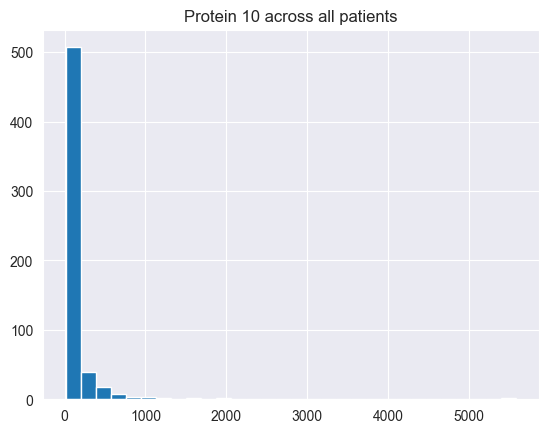

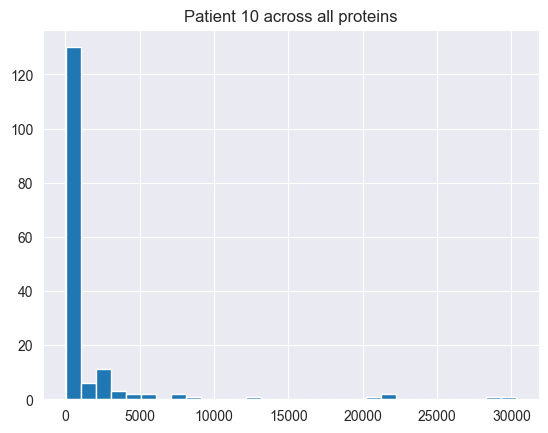

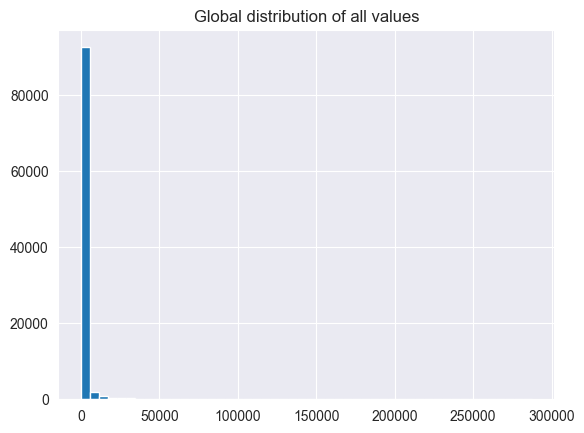

In [20]:
# One protein across all patients
protein_row = numeric_clean.iloc[10]
protein_row.hist(bins=30)
plt.title("Protein 10 across all patients")
plt.show()

# One patient across all proteins
patient_column = numeric_clean.iloc[:, 10]
patient_column.hist(bins=30)
plt.title("Patient 10 across all proteins")
plt.show()

# Whole dataset distribution
all_values = numeric_clean.stack()
all_values.hist(bins=50)
plt.title("Global distribution of all values")
plt.show()


## Check sample count by visit _BL vs _M6

In [25]:
#bl_count = sum(str(col).endswith("_BL") for col in initial_autoimmune_dataset.columns)
#m6_count = sum(str(col).endswith("_M6") for col in initial_autoimmune_dataset.columns)

#print("BL columns:", bl_count)
#print("M6 columns:", m6_count)

bl_count = sum(str(col).endswith("_BL") for col in initial_autoimmune_dataset_ra_only.columns)
m6_count = sum(str(col).endswith("_M6") for col in initial_autoimmune_dataset_ra_only.columns)

print("BL columns:", bl_count)
print("M6 columns:", m6_count)

#bl_count = sum("_BL" in str(x) for x in initial_autoimmune_dataset_ra_only_transposed["Patient_Timepoint"])
#m6_count = sum("_M6" in str(x) for x in initial_autoimmune_dataset_ra_only_transposed["Patient_Timepoint"])

#print(bl_count, m6_count)

BL columns: 265
M6 columns: 235


## Get patient count

In [23]:
patient_ids = [col.rsplit("_", 1)[0]
    for col in initial_autoimmune_dataset.columns
    if "_" in col
]

len(set(patient_ids))

318

## Check for control group in data set

In [24]:
#vac_count = sum(col.startswith("VAC") for col in initial_autoimmune_dataset.columns)
#tac_count = sum(col.startswith("TAC") for col in initial_autoimmune_dataset.columns)

vac_count = sum(col.startswith("VAC") for col in initial_autoimmune_dataset_ra_only.columns)
tac_count = sum(col.startswith("TAC") for col in initial_autoimmune_dataset_ra_only.columns)

print("VAC", vac_count)
print("TAC:", tac_count)

VAC 0
TAC: 500
